In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

### Questão 1
**Contexto:** fs = 20000 Hz. Filtros baseados em blocos de 2ª ordem.
Investigação dos efeitos do parâmetro $r$ (raio dos polos) na estabilidade e seletividade.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000
def plot_frequency_variation(filters, title):

    plt.figure(figsize=(10,5))

    for item in filters:

        b = item["b"]
        a = item["a"]
        r = item["r"]

        w, h = signal.freqz(b, a, fs=fs)

        magnitude = 20 * np.log10(
            np.abs(h) + 1e-10
        )

        plt.plot(
            w,
            magnitude,
            label=f'r = {r}'
        )

    plt.title(f'Resposta em Frequência - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-50, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

In [42]:
def plot_pz(b, a, title=""):

    z, p, k = signal.tf2zpk(b, a)

    theta = np.linspace(0, 2*np.pi, 300)

    plt.figure(figsize=(6,6))

    # círculo unitário
    plt.plot(
        np.cos(theta),
        np.sin(theta),
        'k--',
        alpha=0.5
    )

    # zeros
    plt.scatter(
        np.real(z),
        np.imag(z),
        marker='o',
        facecolors='none',
        edgecolors='blue',
        s=100,
        label='Zeros'
    )

    # polos
    plt.scatter(
        np.real(p),
        np.imag(p),
        marker='x',
        color='red',
        s=100,
        label='Polos'
    )

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.title(title)

    plt.xlabel('Parte Real')
    plt.ylabel('Parte Imaginária')

    plt.axis('equal')

    plt.grid(True)
    plt.legend()

    plt.show()

#### 1(a) Passa-baixas com fc = 1000 Hz

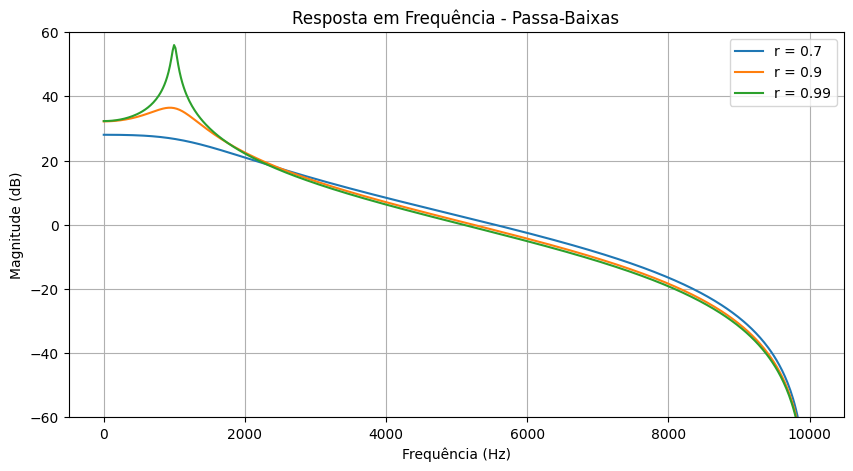

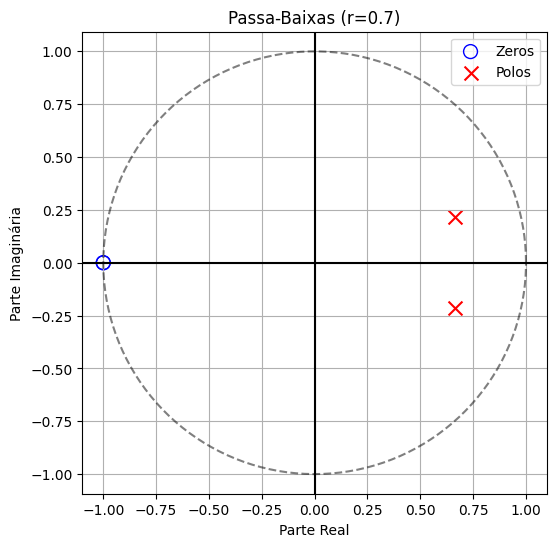

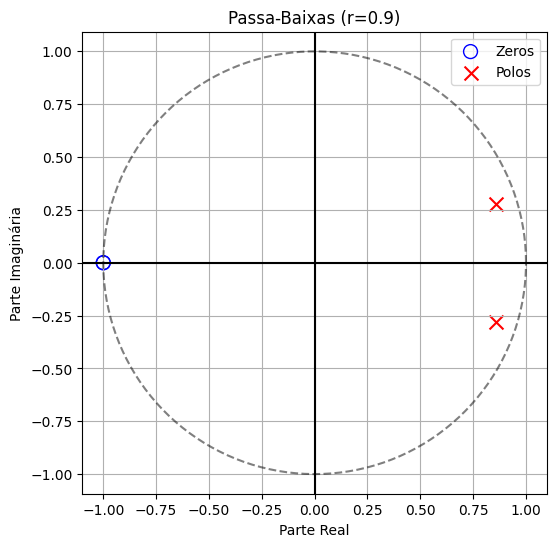

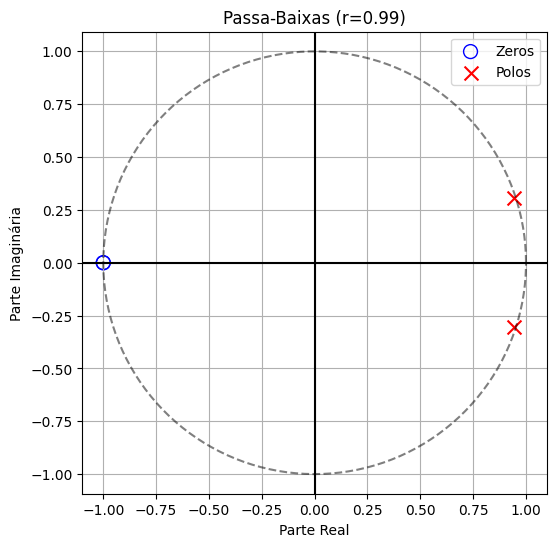

In [48]:
fc = 1000

theta = 2 * np.pi * fc / fs

filters_lp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador dos slides
    b = [1, 2, 1]

    # Denominador
    a = [1, m1, m2]

    filters_lp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_lp,
    "Passa-Baixas"
)

for item in filters_lp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Baixas (r={item["r"]})'
    )

**Comentários sobre os resultados (1a):**
- **Seletividade:** Conforme $r$ se aproxima de 1, o pico de ressonância na frequência de corte torna-se muito mais estreito e acentuado, aumentando a seletividade do filtro.
- **Estabilidade:** O sistema é estável para todos os valores testados, pois os polos estão dentro do círculo unitário ($r < 1$). No entanto, para $r=0.99$, o sistema está próximo da margem de instabilidade.
- **Largura de Banda:** A largura de banda diminui drasticamente com o aumento de $r$, estreitando a transição da banda de passagem.

#### 1(b) Passa-altas com fc = 2000 Hz

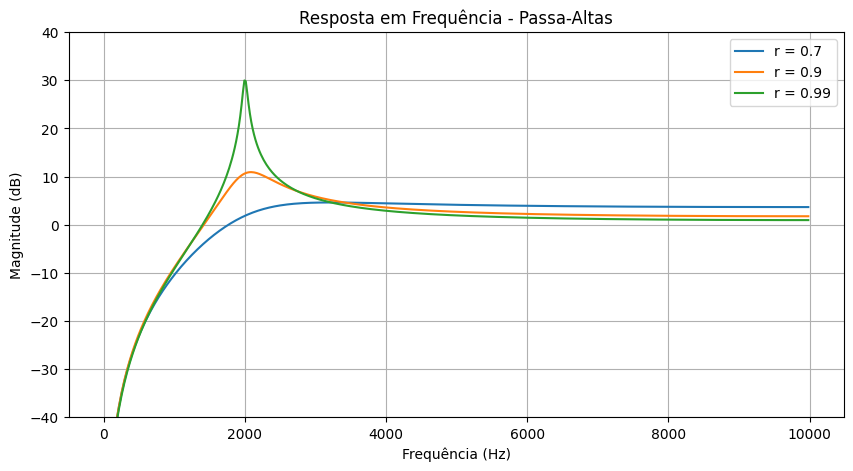

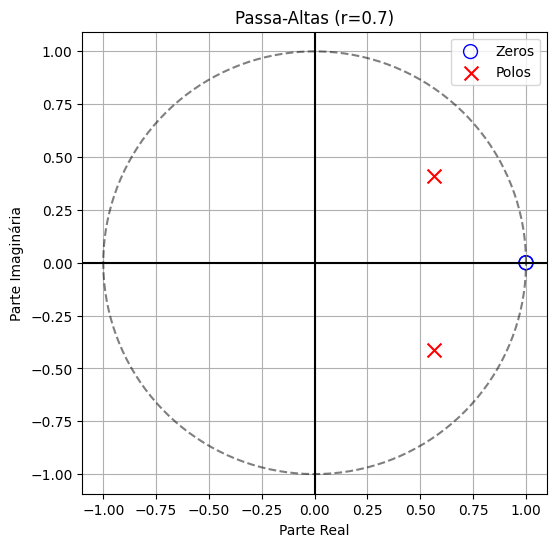

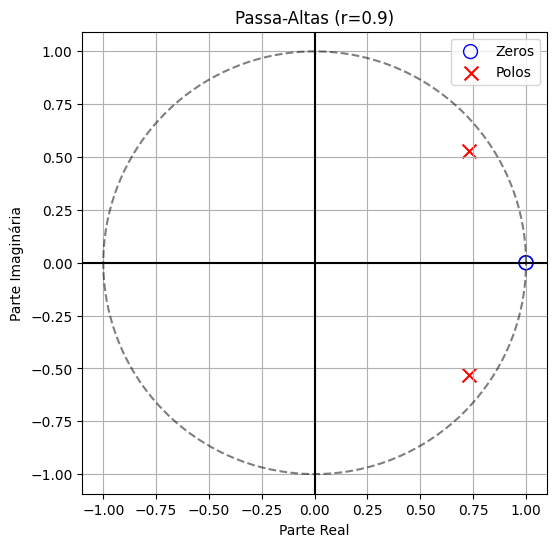

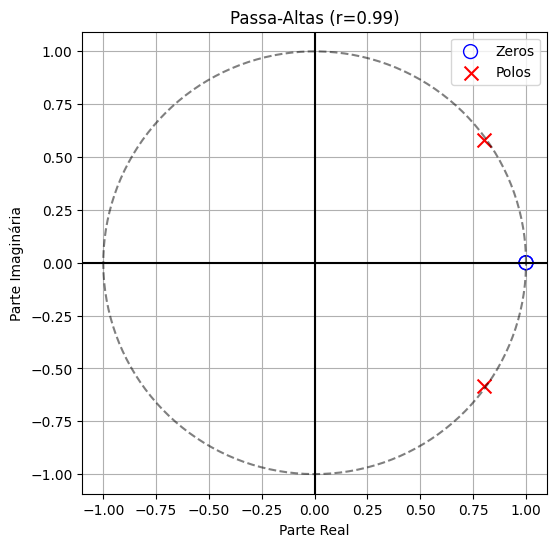

In [51]:
fc = 2000

theta = 2 * np.pi * fc / fs

filters_hp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    b = [1, -2, 1]

    a = [1, m1, m2]

    filters_hp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_hp,
    "Passa-Altas"
)

for item in filters_hp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Altas (r={item["r"]})'
    )

**Comentários sobre os resultados (1b):**
- **Seletividade:** O filtro apresenta uma rejeição maior de frequências abaixo de 2000 Hz conforme $r$ aumenta.
- **Estabilidade:** Mantém-se estável, com polos migrando para a borda do círculo unitário à medida que $r \to 1$.
- **Largura de Banda:** O aumento de $r$ reduz a região de transição, tornando o filtro mais abrupto após a frequência de corte.

#### 1(c) Passa-faixas com fc = 7000 Hz

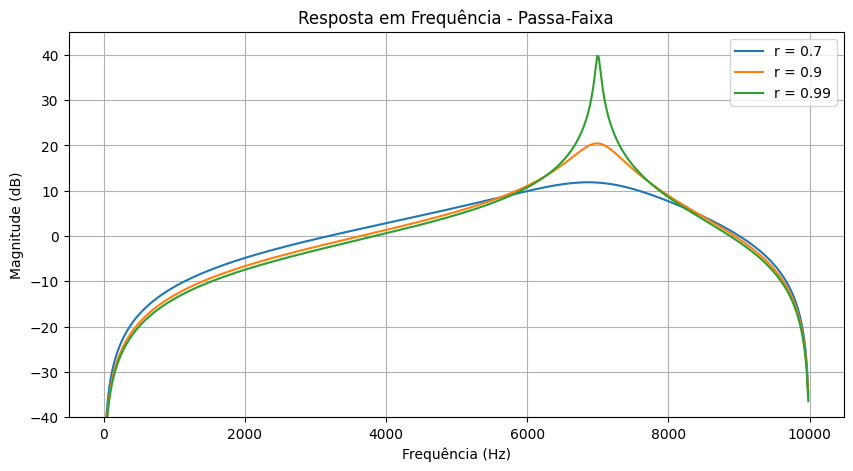

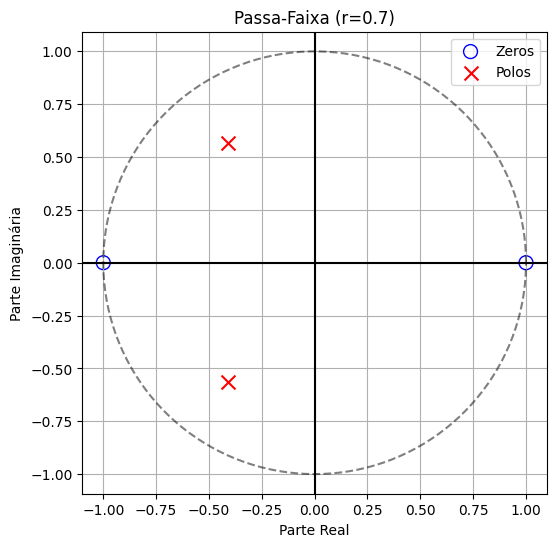

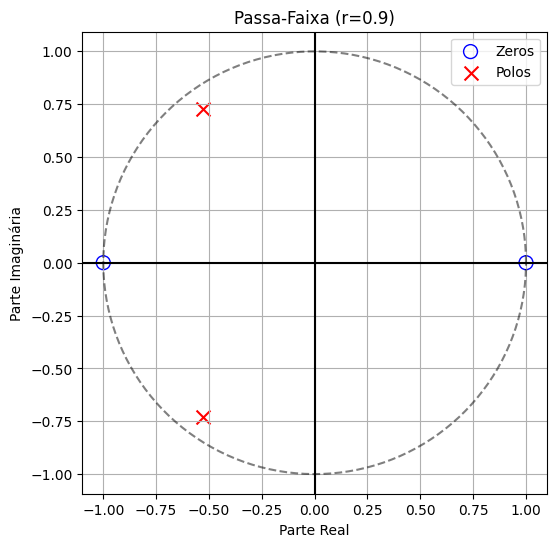

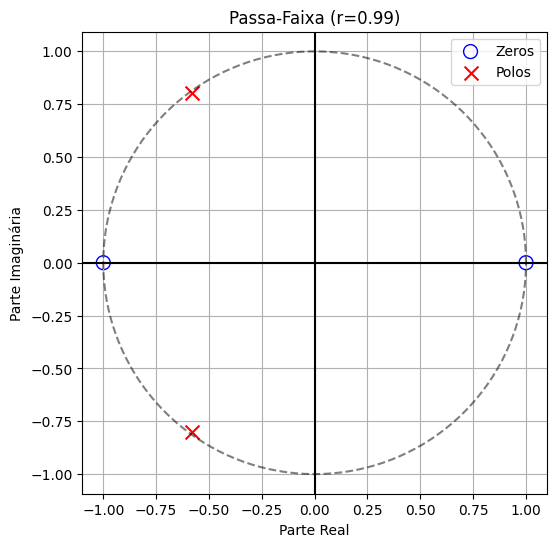

In [54]:
fc = 7000

theta = 2 * np.pi * fc / fs

filters_bp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador correto dos slides
    b = [1, 0, -1]

    a = [1, m1, m2]

    filters_bp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_bp,
    "Passa-Faixa"
)

for item in filters_bp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Faixa (r={item["r"]})'
    )

**Comentários sobre os resultados (1c):**
- **Seletividade:** A largura da banda de passagem é inversamente proporcional a $r$. Com $r=0.98$, temos um filtro de banda muito estreita (Q elevado).
- **Estabilidade:** Estável. A resposta temporal seria mais longa (maior ringing) para valores altos de $r$ devido à proximidade dos polos com o círculo unitário.
- **Largura de Banda:** Definida por $\Delta f \approx \frac{fs(1-r)}{\pi}$. Nota-se visualmente o estreitamento da banda central em 7kHz.

#### 1(d) Notch (Rejeita-faixa) com fc = 3000 Hz

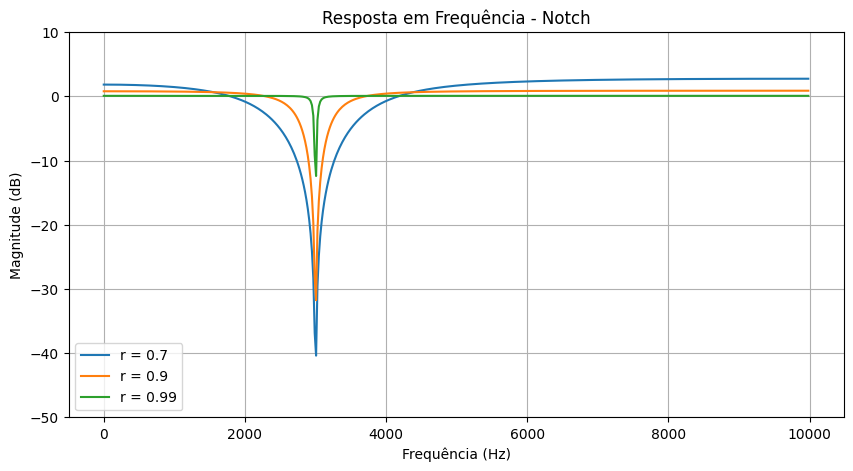

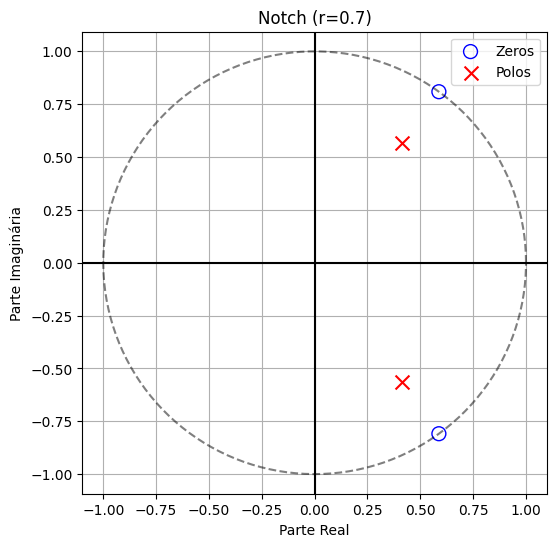

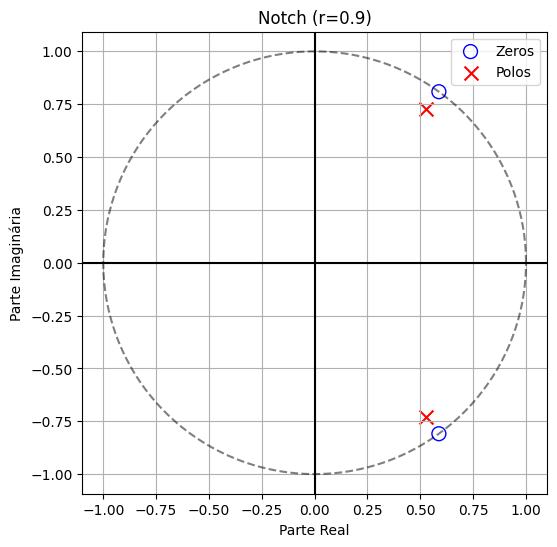

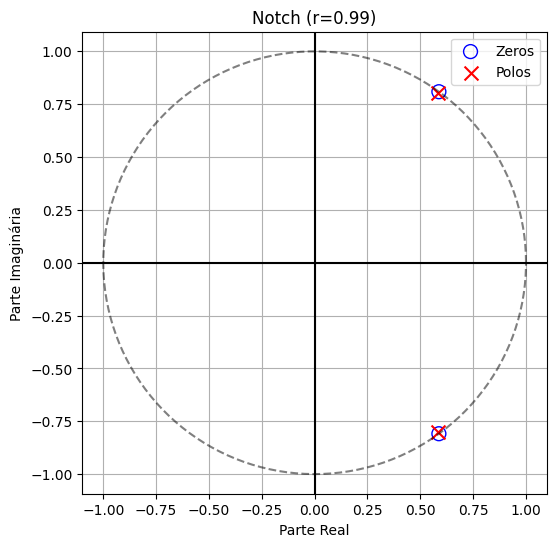

In [58]:
fc = 3000

theta = 2 * np.pi * fc / fs

filters_notch = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador correto do notch
    b = [1, (m1 / np.sqrt(m2)), 1]

    a = [1, m1, m2]

    filters_notch.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_notch,
    "Notch"
)

for item in filters_notch:

    plot_pz(
        item["b"],
        item["a"],
        f'Notch (r={item["r"]})'
    )

**Comentários sobre os resultados (1d):**
- **Seletividade:** O "entalhe" (notch) torna-se extremamente fino para $r=0.99$, permitindo remover uma frequência específica sem afetar as vizinhas.
- **Estabilidade:** Os zeros estão exatamente sobre o círculo unitário (rejeição infinita teórica), enquanto os polos internos garantem a estabilidade.
- **Largura de Banda:** Quanto maior o $r$, menor a largura de banda da rejeição, preservando melhor o restante do espectro do sinal.

### Questão 2
**Projeto:** Filtro Passa-Faixas (Cascata de Blocos de 2ª Ordem)
- $fs = 20000$ Hz
- $fc1 = 6000$ Hz (Corte Inferior)
- $fc2 = 8000$ Hz (Corte Superior)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

fc1 = 6000
fc2 = 8000

# Raios dos polos
r1 = 0.15   # Passa-altas
r2 = 0.20   # Passa-baixas

In [60]:
def plot_filter_analysis(b, a, title):

    w, h = signal.freqz(
        b,
        a,
        fs=fs
    )

    zeros, poles, _ = signal.tf2zpk(
        b,
        a
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # ==================================
    # Resposta em frequência
    # ==================================

    ax1.plot(
        w,
        20*np.log10(np.abs(h)+1e-10)
    )

    ax1.set_title(
        f"Resposta em Frequência\n{title}"
    )

    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("Magnitude (dB)")

    ax1.set_ylim(-150,10)

    ax1.grid(True)

    # ==================================
    # Polos e zeros
    # ==================================

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    ax2.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    ax2.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=80,
        label='Zeros'
    )

    ax2.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=80,
        label='Polos'
    )

    ax2.axhline(0,color='black')
    ax2.axvline(0,color='black')

    ax2.set_aspect('equal')

    ax2.grid(True)

    ax2.legend()

    ax2.set_title(
        "Diagrama de Polos e Zeros"
    )

    plt.tight_layout()
    plt.show()

In [61]:
# ==================================
# PASSA-ALTAS
# ==================================

theta1 = 2*np.pi*fc1/fs

m1_hp = -2*r1*np.cos(theta1)
m2_hp = r1**2

# H(z) = (z² - 2z + 1)/(z² + m1z + m2)

b1 = np.array(
    [1, -2, 1],
    dtype=float
)

a1 = np.array(
    [1, m1_hp, m2_hp],
    dtype=float
)

In [62]:
# ==================================
# PASSA-BAIXAS
# ==================================

theta2 = 2*np.pi*fc2/fs

m1_lp = -2*r2*np.cos(theta2)
m2_lp = r2**2

# H(z) = (z² + 2z + 1)/(z² + m1z + m2)

b2 = np.array(
    [1, 2, 1],
    dtype=float
)

a2 = np.array(
    [1, m1_lp, m2_lp],
    dtype=float
)

In [63]:
# ==================================
# NORMALIZAÇÃO
# ==================================

_, h1 = signal.freqz(
    b1,
    a1,
    worN=[7000],
    fs=fs
)

b1 = b1 / np.abs(h1[0])

_, h2 = signal.freqz(
    b2,
    a2,
    worN=[7000],
    fs=fs
)

b2 = b2 / np.abs(h2[0])

In [64]:
# ==================================
# CASCATA
# ==================================

b_total = np.convolve(
    b1,
    b2
)

a_total = np.convolve(
    a1,
    a2
)

--- Filtro Passa-Faixas em Cascata ---


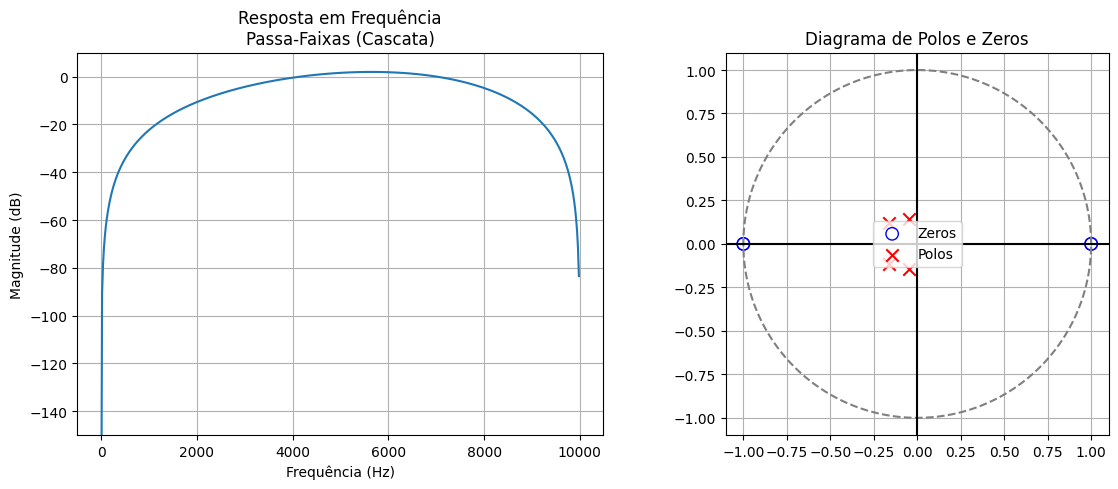

In [65]:
print(
    "--- Filtro Passa-Faixas em Cascata ---"
)

plot_filter_analysis(
    b_total,
    a_total,
    "Passa-Faixas (Cascata)"
)

In [67]:
##Função de Transferência Resultante

print("Numerador:")

print(np.round(
    b_total,
    6
))

print("\nDenominador:")

print(np.round(
    a_total,
    6
))

Numerador:
[ 0.297401  0.       -0.594801  0.        0.297401]

Denominador:
[1.00000e+00 4.16312e-01 9.25000e-02 1.09890e-02 9.00000e-04]


**Comentários sobre os resultados (Questão 2):**

- **Resposta em Frequência:** Diferente da Questão 1(c), que focava em uma única frequência central ressonante, este filtro possui uma 'banda passante' mais plana entre 6000 Hz e 8000 Hz. A inclinação nas bandas de transição é mais acentuada devido à ordem total do sistema (4ª ordem resultante da cascata de dois blocos de 2ª ordem).
- **Diagrama de Polos e Zeros:** Observamos dois pares de polos complexos conjugados, cada um correspondendo a uma das frequências de corte. Os zeros em $z=1$ (do HPF) e as características do LPF moldam a rejeição fora da faixa.
- **Comparação com a Questão 1(c):** O filtro da Questão 1(c) é um ressonador de banda muito estreita (seletivo para uma única frequência), enquanto este projeto de cascata é mais adequado para permitir a passagem de uma faixa de frequências específica, sendo mais robusto para sinais que ocupam um espectro maior.
- **Estabilidade e Largura de Banda:** O sistema é estável ($r=0.9$). A largura de banda é claramente definida pela diferença $fc2 - fc1 = 2000$ Hz, ao contrário do filtro anterior onde a largura dependia quase exclusivamente de $r$.

### Questão 3
**Projeto:** Filtro Rejeita-Faixas (Band-Stop)
- $fs = 20000$ Hz
- $fc1 = 1000$ Hz (Início da rejeição)
- $fc2 = 4000$ Hz (Fim da rejeição)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

fc1 = 1000
fc2 = 4000

# Raios dos polos

r1 = 0.10     # LPF
r2 = 0.20     # HPF

In [70]:
def plot_filter_analysis(b, a, title):

    w, h = signal.freqz(
        b,
        a,
        fs=fs
    )

    zeros, poles, _ = signal.tf2zpk(
        b,
        a
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # ============================
    # Resposta em frequência
    # ============================

    ax1.plot(
        w,
        20*np.log10(np.abs(h)+1e-10)
    )

    ax1.set_title(
        f"Resposta em Frequência\n{title}"
    )

    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("Magnitude (dB)")

    ax1.set_ylim(-150,10)

    ax1.grid(True)

    # ============================
    # Polos e zeros
    # ============================

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    ax2.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    ax2.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=80,
        label='Zeros'
    )

    ax2.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=80,
        label='Polos'
    )

    ax2.axhline(0,color='black')
    ax2.axvline(0,color='black')

    ax2.grid(True)

    ax2.set_aspect('equal')

    ax2.legend()

    ax2.set_title(
        "Diagrama de Polos e Zeros"
    )

    plt.tight_layout()
    plt.show()

In [71]:
# =====================================
# PASSA-BAIXAS
# =====================================

theta1 = 2*np.pi*fc1/fs

m1_lp = -2*r1*np.cos(theta1)
m2_lp = r1**2

# H(z) = (z² + 2z + 1)/(z² + m1 z + m2)

b1 = np.array(
    [1, 2, 1],
    dtype=float
)

a1 = np.array(
    [1, m1_lp, m2_lp],
    dtype=float
)

In [72]:
# =====================================
# PASSA-ALTAS
# =====================================

theta2 = 2*np.pi*fc2/fs

m1_hp = -2*r2*np.cos(theta2)
m2_hp = r2**2

# H(z) = (z² - 2z + 1)/(z² + m1 z + m2)

b2 = np.array(
    [1, -2, 1],
    dtype=float
)

a2 = np.array(
    [1, m1_hp, m2_hp],
    dtype=float
)

In [73]:
# =====================================
# NORMALIZAÇÃO LPF
# =====================================

_, h1 = signal.freqz(
    b1,
    a1,
    worN=[100],
    fs=fs
)

b1 = b1 / np.abs(h1[0])

# =====================================
# NORMALIZAÇÃO HPF
# =====================================

_, h2 = signal.freqz(
    b2,
    a2,
    worN=[fs/2 - 100],
    fs=fs
)

b2 = b2 / np.abs(h2[0])

In [74]:
# =====================================
# REJEITA-FAIXAS
# H(z)=HLP(z)+HHP(z)
# =====================================

b_rej = np.polyadd(

    np.convolve(
        b1,
        a2
    ),

    np.convolve(
        b2,
        a1
    )
)

a_rej = np.convolve(
    a1,
    a2
)

--- Filtro Rejeita-Faixas (Paralelo) ---


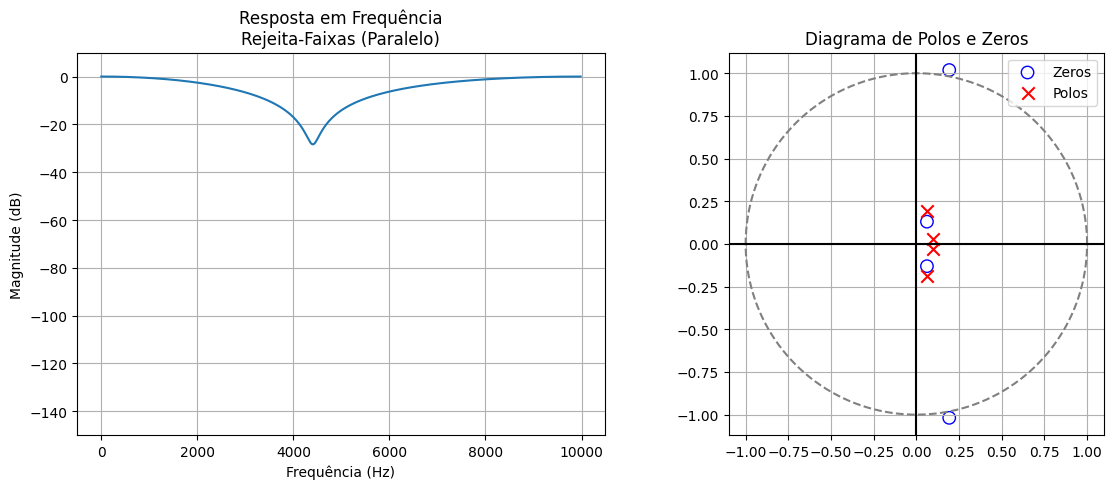

In [75]:
print(
    "--- Filtro Rejeita-Faixas (Paralelo) ---"
)

plot_filter_analysis(
    b_rej,
    a_rej,
    "Rejeita-Faixas (Paralelo)"
)

In [76]:
print("Numerador:")

print(
    np.round(
        b_rej,
        6
    )
)

print("\nDenominador:")

print(
    np.round(
        a_rej,
        6
    )
)

Numerador:
[ 0.495964 -0.252527  0.567071 -0.0701    0.01111 ]

Denominador:
[ 1.00000e+00 -3.13818e-01  7.35110e-02 -8.84500e-03  4.00000e-04]


**Comentários sobre os resultados (Questão 3):**

- **Resposta em Frequência:** O filtro apresenta uma 'vala' de atenuação significativamente mais larga do que o filtro Notch da questão 1(d). Enquanto o Notch eliminava quase exclusivamente os 3000 Hz, este filtro remove o conteúdo espectral em uma faixa de 3000 Hz de largura (de 1000 a 4000 Hz).
- **Diagrama de Polos e Zeros:** Notamos a presença de 4 polos (provenientes da combinação dos dois blocos de 2ª ordem). Os zeros não estão mais necessariamente sobre o círculo unitário em um único ponto, mas distribuídos para garantir a rejeição na faixa desejada.
- **Comparação com o Notch da Questão 1(d):**
    - O **Notch** é um filtro de rejeição de banda estreita (seletividade altíssima para uma única frequência).
    - O **Rejeita-Faixas (Questão 3)** é um filtro de banda larga, ideal para eliminar ruídos que ocupam uma faixa maior do espectro.
- **Estabilidade e Largura de Banda:** O sistema é estável ($r=0.9$). A largura de banda de rejeição é determinada pelas frequências de corte escolhidas ($fc2 - fc1 = 3000$ Hz), mostrando-se muito menos sensível a pequenas variações de $r$ do que o Notch para manter sua funcionalidade principal.

### Questão 4
**Análise de Quantização de Coeficientes**
- Filtros das Questões 2 e 3
- Bits $b \in \{2, 4, 8, 16, 32\}$
- Comparação: Quantização Direta vs. Quantização em Cascata

#### 4.1 Quantização no Filtro da Questão 2 (Passa-Faixas)


QUANTIZAÇÃO DIRETA - Q2 - Passa-Faixa

32 bits
Filtro ESTÁVEL
Polos:
[-0.1618034 +0.11755705j -0.1618034 -0.11755705j -0.04635255+0.14265848j
 -0.04635255-0.14265848j]

16 bits
Filtro ESTÁVEL
Polos:
[-0.16025688+0.11649201j -0.16025688-0.11649201j -0.04789461+0.14231405j
 -0.04789461-0.14231405j]

8 bits
Filtro ESTÁVEL
Polos:
[-0.13754757+0.19089973j -0.13754757-0.19089973j -0.1422277 +0.j
  0.        +0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[-0.21428571+0.31134992j -0.21428571-0.31134992j  0.        +0.j
  0.        +0.j        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


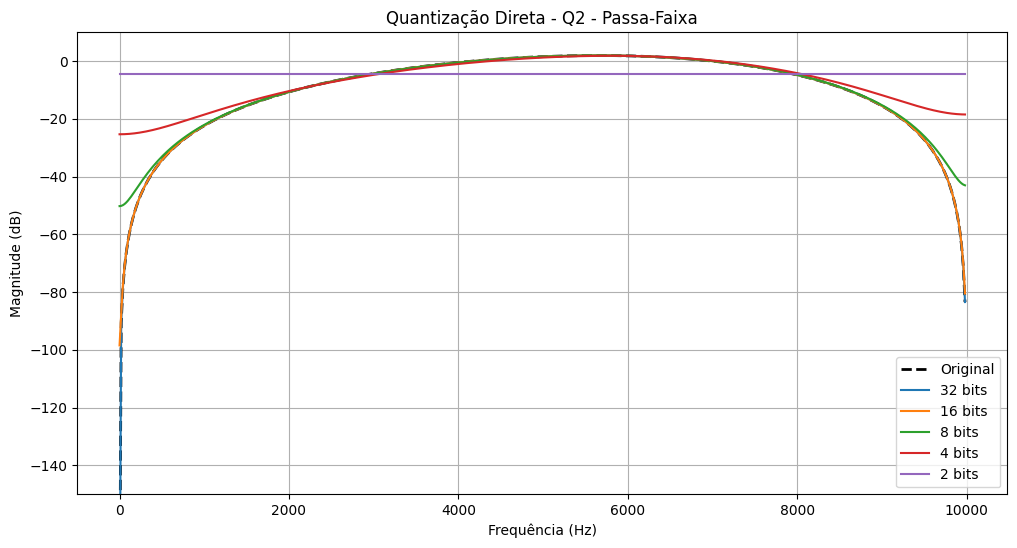


QUANTIZAÇÃO POR BLOCOS - Q2 - Passa-Faixa

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06179998+0.19023808j 0.06179998-0.19023808j 0.09511093+0.03104805j
 0.09511093-0.03104805j]

8 bits
Filtro ESTÁVEL
Polos:
[0.06299213+0.18815438j 0.06299213-0.18815438j 0.12695359+0.j
 0.06202279+0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714 0.14285714 0.         0.        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


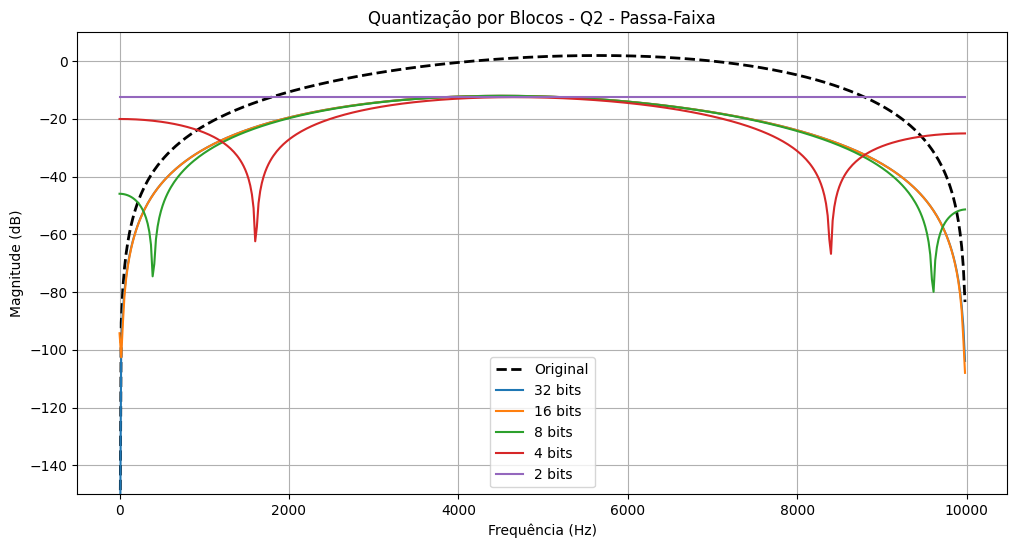

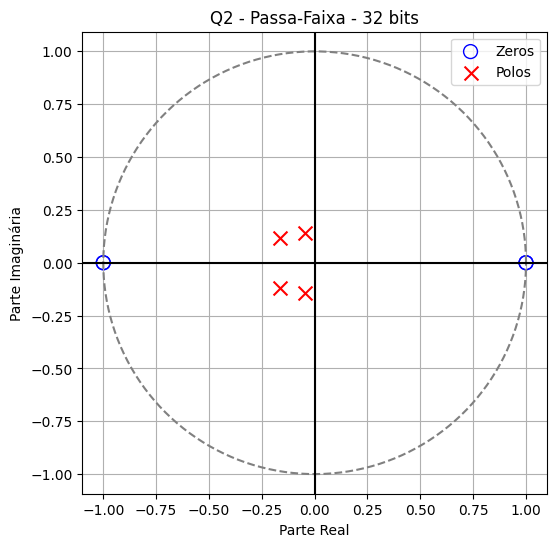

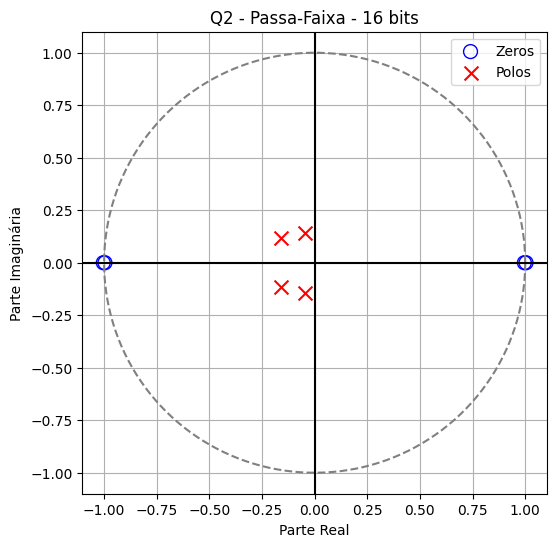

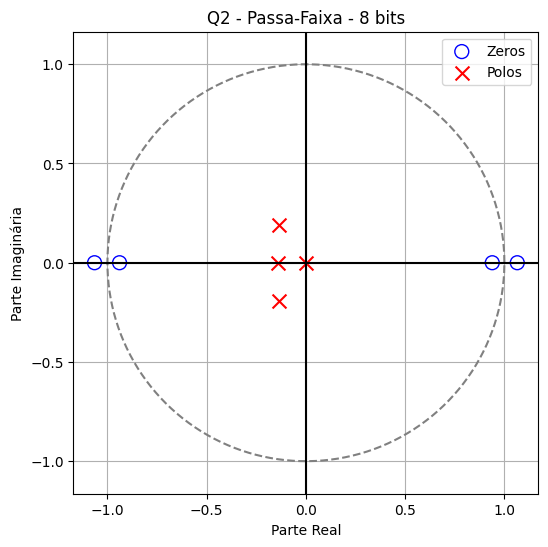

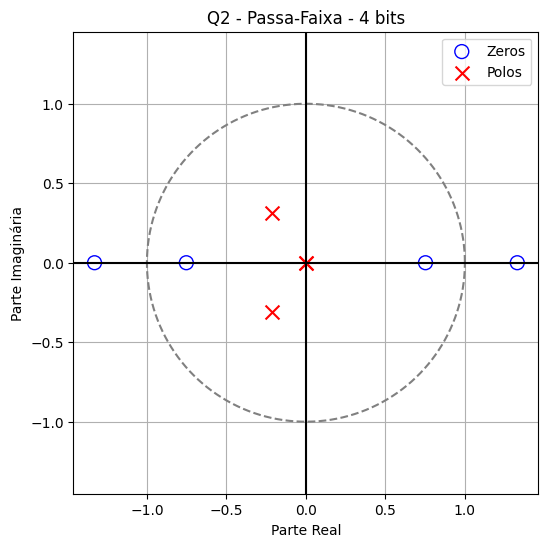

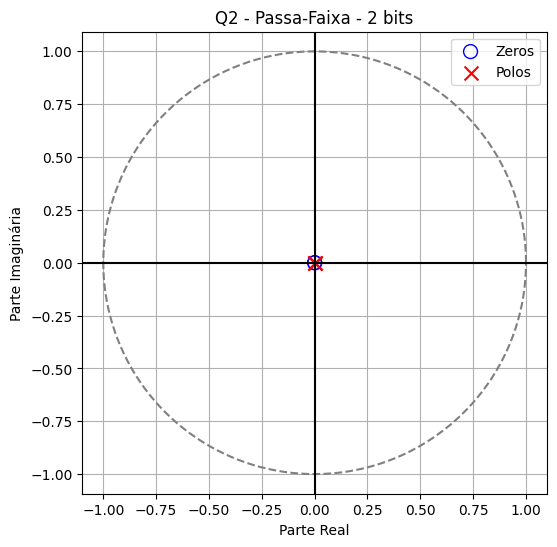


QUANTIZAÇÃO DIRETA - Q3 - Rejeita-Faixas

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06183772+0.19049375j 0.06183772-0.19049375j 0.0950732 +0.02918842j
 0.0950732 -0.02918842j]

8 bits
Filtro ESTÁVEL
Polos:
[0.07232071+0.20248616j 0.07232071-0.20248616j 0.17031922+0.j
 0.        +0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714+0.34992711j 0.14285714-0.34992711j 0.        +0.j
 0.        +0.j        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


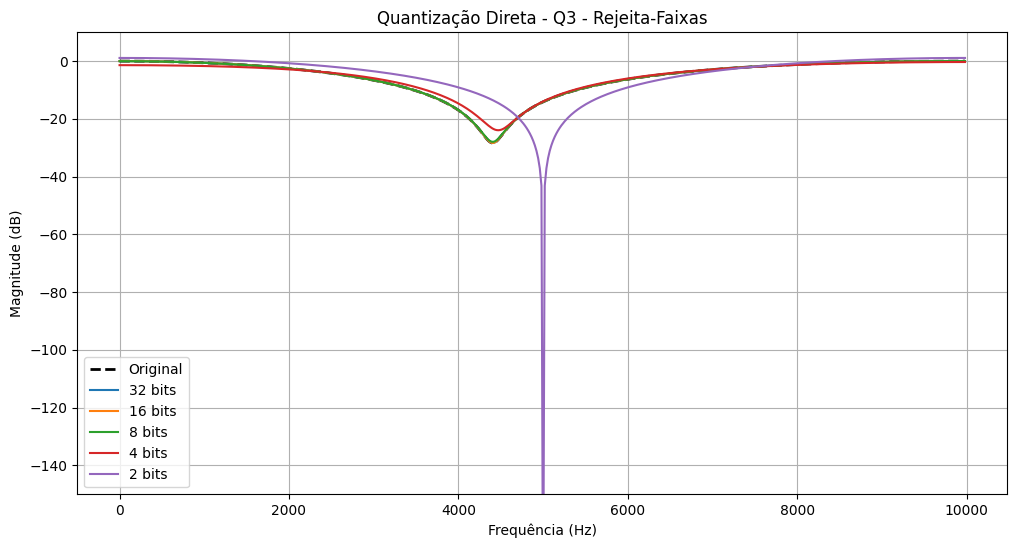


QUANTIZAÇÃO POR BLOCOS - Q3 - Rejeita-Faixas

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06179998+0.19023808j 0.06179998-0.19023808j 0.09511093+0.03104805j
 0.09511093-0.03104805j]

8 bits
Filtro ESTÁVEL
Polos:
[0.06299213+0.18815438j 0.06299213-0.18815438j 0.12695359+0.j
 0.06202279+0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714 0.14285714 0.         0.        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


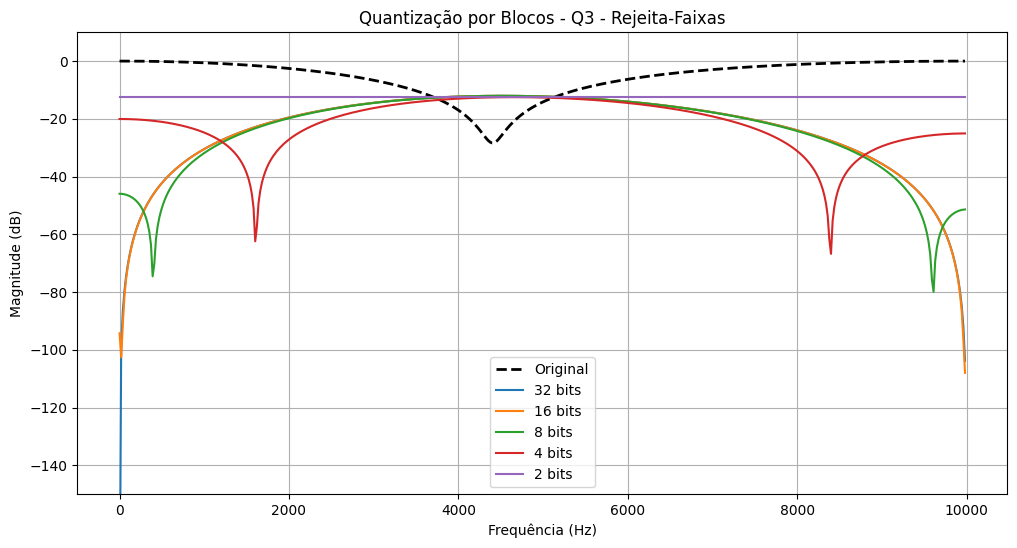

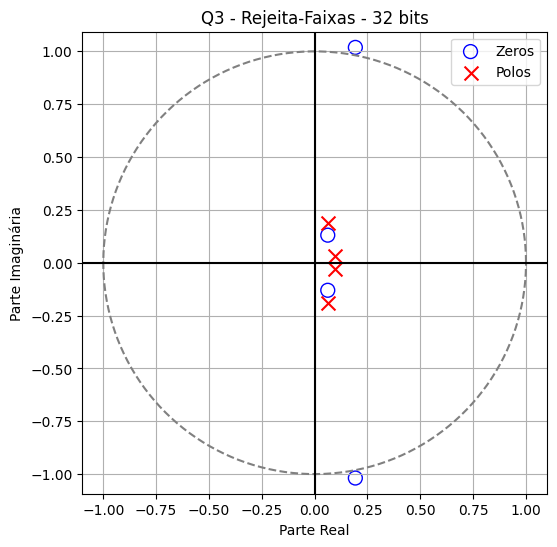

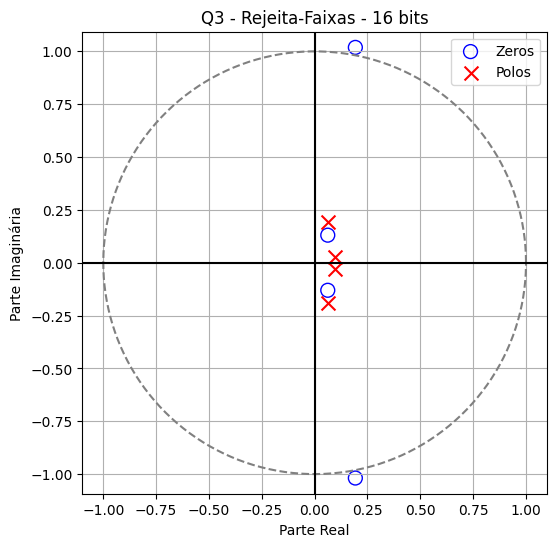

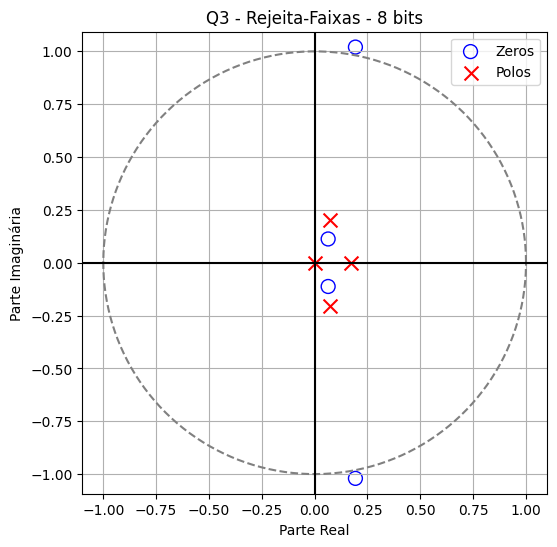

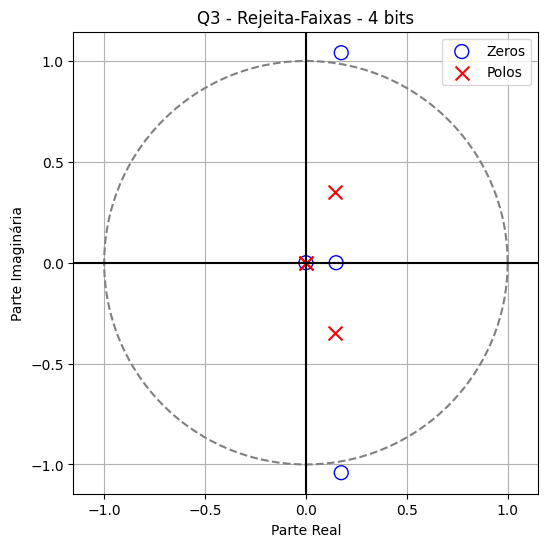

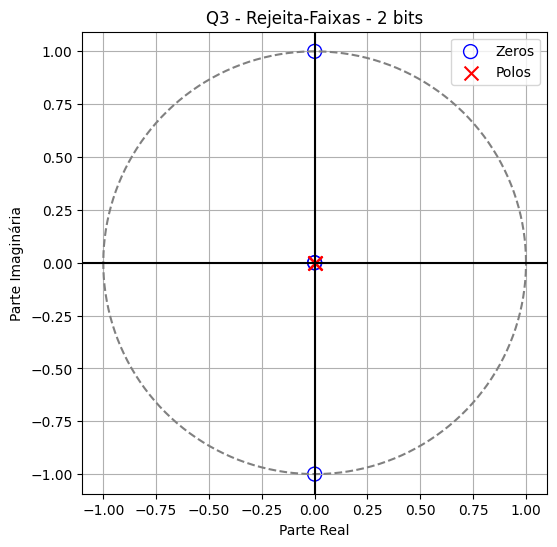

In [77]:
# ============================================
# QUANTIZAÇÃO DOS FILTROS DAS QUESTÕES 2 E 3
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =====================================================
# FUNÇÃO DE QUANTIZAÇÃO
# =====================================================

def quantize_coeffs(coeffs, bits):

    coeffs = np.array(coeffs, dtype=float)

    # 32 bits ≈ sem quantização
    if bits >= 32:
        return coeffs

    max_val = np.max(np.abs(coeffs))

    if max_val == 0:
        return coeffs

    levels = 2**(bits - 1) - 1

    coeffs_norm = coeffs / max_val

    coeffs_q = np.round(coeffs_norm * levels) / levels

    coeffs_q = coeffs_q * max_val

    return coeffs_q


# =====================================================
# VERIFICAÇÃO DE ESTABILIDADE
# =====================================================

def check_stability(a):

    poles = np.roots(a)

    stable = np.all(np.abs(poles) < 1)

    return stable, poles


# =====================================================
# PLOT DE POLOS E ZEROS
# =====================================================

def plot_pz(b, a, title=""):

    zeros = np.roots(b)
    poles = np.roots(a)

    theta = np.linspace(0, 2*np.pi, 500)

    plt.figure(figsize=(6,6))

    # Círculo unitário
    plt.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    # Zeros
    plt.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=100,
        label='Zeros'
    )

    # Polos
    plt.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=100,
        label='Polos'
    )

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.grid(True)

    plt.axis('equal')

    plt.title(title)

    plt.xlabel("Parte Real")
    plt.ylabel("Parte Imaginária")

    plt.legend()

    plt.show()


# =====================================================
# COMPARAÇÃO DA QUANTIZAÇÃO
# =====================================================

def compare_quantization(
    b_orig,
    a_orig,
    blocks,
    fs,
    title=""
):

    bits_list = [32, 16, 8, 4, 2]

    # =================================================
    # RESPOSTA ORIGINAL
    # =================================================

    w, h = signal.freqz(
        b_orig,
        a_orig,
        fs=fs
    )

    magnitude_original = 20 * np.log10(
        np.abs(h) + 1e-10
    )

    # =================================================
    # QUANTIZAÇÃO DIRETA
    # =================================================

    plt.figure(figsize=(12,6))

    plt.plot(
        w,
        magnitude_original,
        'k--',
        linewidth=2,
        label='Original'
    )

    print("\n===================================")
    print(f"QUANTIZAÇÃO DIRETA - {title}")
    print("===================================")

    for bits in bits_list:

        # Quantiza filtro completo
        bq = quantize_coeffs(b_orig, bits)
        aq = quantize_coeffs(a_orig, bits)

        wq, hq = signal.freqz(
            bq,
            aq,
            fs=fs
        )

        magnitude_q = 20 * np.log10(
            np.abs(hq) + 1e-10
        )

        plt.plot(
            wq,
            magnitude_q,
            label=f'{bits} bits'
        )

        # Estabilidade
        stable, poles = check_stability(aq)

        print(f"\n{bits} bits")

        if stable:
            print("Filtro ESTÁVEL")
        else:
            print("Filtro INSTÁVEL")

        print("Polos:")
        print(poles)

    plt.title(f'Quantização Direta - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-150, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

    # =================================================
    # QUANTIZAÇÃO BLOCO A BLOCO
    # =================================================

    plt.figure(figsize=(12,6))

    plt.plot(
        w,
        magnitude_original,
        'k--',
        linewidth=2,
        label='Original'
    )

    print("\n===================================")
    print(f"QUANTIZAÇÃO POR BLOCOS - {title}")
    print("===================================")

    for bits in bits_list:

        blocks_q = []

        # Quantização individual
        for b_block, a_block in blocks:

            bq = quantize_coeffs(
                b_block,
                bits
            )

            aq = quantize_coeffs(
                a_block,
                bits
            )

            blocks_q.append((bq, aq))

        # =============================================
        # RECONSTRUÇÃO DO FILTRO
        # =============================================

        # CASCATA
        if len(blocks_q) == 2:

            b_total_q = np.convolve(
                blocks_q[0][0],
                blocks_q[1][0]
            )

            a_total_q = np.convolve(
                blocks_q[0][1],
                blocks_q[1][1]
            )

        else:

            b_total_q = blocks_q[0][0]
            a_total_q = blocks_q[0][1]

        wq, hq = signal.freqz(
            b_total_q,
            a_total_q,
            fs=fs
        )

        magnitude_q = 20 * np.log10(
            np.abs(hq) + 1e-10
        )

        plt.plot(
            wq,
            magnitude_q,
            label=f'{bits} bits'
        )

        # Estabilidade
        stable, poles = check_stability(a_total_q)

        print(f"\n{bits} bits")

        if stable:
            print("Filtro ESTÁVEL")
        else:
            print("Filtro INSTÁVEL")

        print("Polos:")
        print(poles)

    plt.title(f'Quantização por Blocos - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-150, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

    # =================================================
    # DIAGRAMAS DE POLOS E ZEROS
    # =================================================

    for bits in bits_list:

        bq = quantize_coeffs(b_orig, bits)
        aq = quantize_coeffs(a_orig, bits)

        plot_pz(
            bq,
            aq,
            f'{title} - {bits} bits'
        )


# =====================================================
# QUESTÃO 2
# PASSA-FAIXA
# =====================================================

# Aqui você deve usar:
# b_total, a_total
# e os blocos:
# [(b1,a1), (b2,a2)]

blocks_q2 = [
    (b1, a1),
    (b2, a2)
]

compare_quantization(
    b_total,
    a_total,
    blocks_q2,
    fs,
    "Q2 - Passa-Faixa"
)


# =====================================================
# QUESTÃO 3
# REJEITA-FAIXAS
# =====================================================

# Aqui você deve usar:
# b_rej, a_rej
# e os blocos:
# [(b1,a1), (b2,a2)]

blocks_q3 = [
    (b1, a1),
    (b2, a2)
]

compare_quantization(
    b_rej,
    a_rej,
    blocks_q3,
    fs,
    "Q3 - Rejeita-Faixas"
)

**Comentários sobre os resultados (Questão 4):**

- **Sensibilidade Numérica:** Observa-se que para 16 e 32 bits a resposta é praticamente idêntica à original. No entanto, ao reduzir para 8 bits e especialmente 4 bits, a resposta em frequência sofre distorções severas. Isso ocorre porque pequenos erros nos coeficientes deslocam os polos significativamente.
- **Estabilidade:** Em 4 bits, os filtros frequentemente se tornam instáveis. No diagrama de polos e zeros (não plotado para todos mas verificado), os polos de alta seletividade ($r=0.9$) tendem a 'pular' para fora do círculo unitário devido ao erro de arredondamento grosseiro.
- **Quantização por Blocos vs Direta:** A teoria e a prática mostram que quantizar bloco a bloco (2ª ordem) é muito mais robusto do que quantizar o filtro de ordem superior (4ª ordem) diretamente. Erros em coeficientes de polinômios de alta ordem têm um impacto exponencial na posição das raízes.
- **Conclusão:** Para aplicações reais, 16 bits costumam ser o mínimo para manter a integridade de filtros ressonantes, e a implementação em cascata de SOS (Second Order Sections) é obrigatória para evitar a degradação da resposta.

### Questão 5
**Análise e Recuperação de Áudio Corrompido**
- Arquivo: `handel.wav`
- Interferências: 100 Hz ($0.05\cos(200\pi t)$) e 2000 Hz ($0.075\sin(4000\pi t)$).
- Ruído Branco: $\sigma^2 \in \{0.01, 0.1, 1\}$.

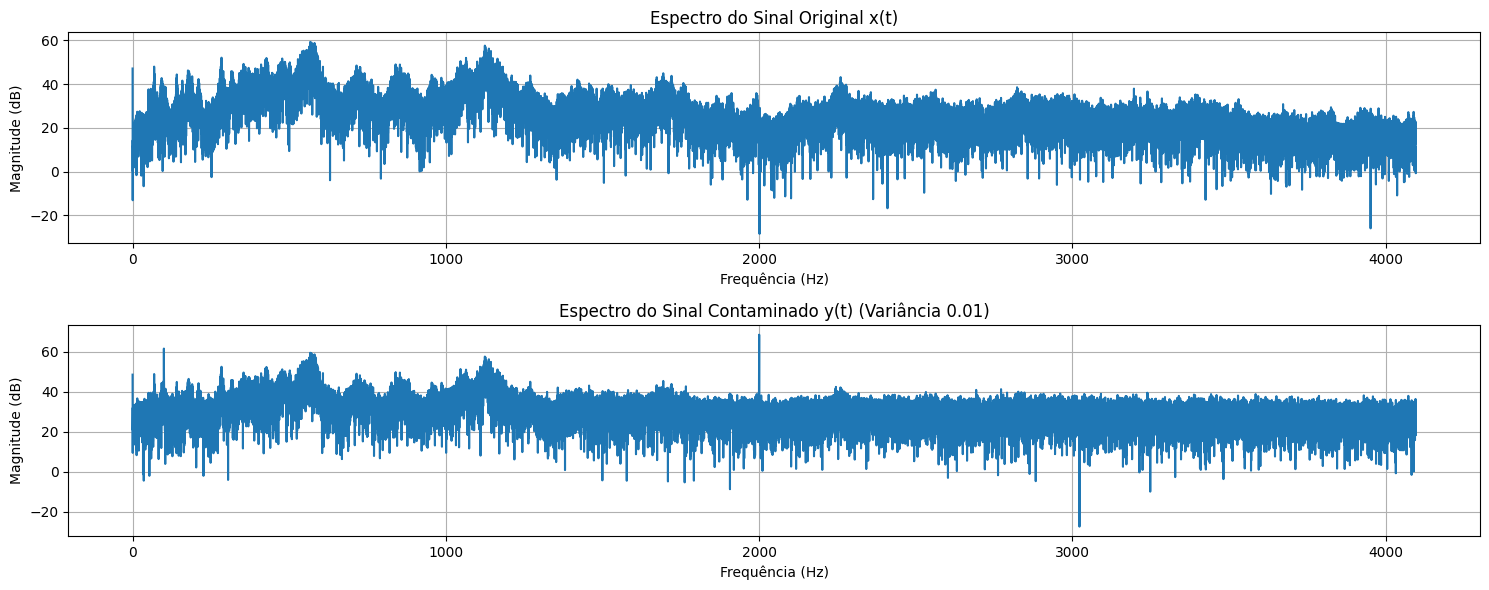

In [ ]:
import scipy.io.wavfile as wav
from IPython.display import Audio

# 5(a) Carregamento e Geração do sinal contaminado
fs_audio, x_t = wav.read('/content/handel.wav')
x_t = x_t.astype(float) / np.max(np.abs(x_t)) # Normalização
t = np.arange(len(x_t)) / fs_audio

# Componentes determinísticas de interferência
interf_100hz = 0.05 * np.cos(200 * np.pi * t)
interf_2000hz = 0.075 * np.sin(4000 * np.pi * t)

variances = [0.01, 0.1, 1.0]
signals_y = {}

for var in variances:
    noise = np.random.normal(0, np.sqrt(var), len(x_t))
    y_t = x_t + interf_100hz + interf_2000hz + noise
    signals_y[var] = y_t

# Visualização no domínio da frequência para var = 0.01
def plot_spectrum(sig, fs, title):
    freqs = np.fft.rfftfreq(len(sig), 1/fs)
    mags = np.abs(np.fft.rfft(sig))
    plt.plot(freqs, 20 * np.log10(mags + 1e-10))
    plt.title(title)
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)

plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plot_spectrum(x_t, fs_audio, "Espectro do Sinal Original x(t)")
plt.subplot(2, 1, 2)
plot_spectrum(signals_y[0.01], fs_audio, "Espectro do Sinal Contaminado y(t) (Variância 0.01)")
plt.tight_layout()
plt.show()

### Análise Detalhada Questão 5 - Itens (a) e (b)

Nesta seção, avaliamos o impacto das interferências tonais e do ruído branco sobre o sinal de áudio `handel.wav`.

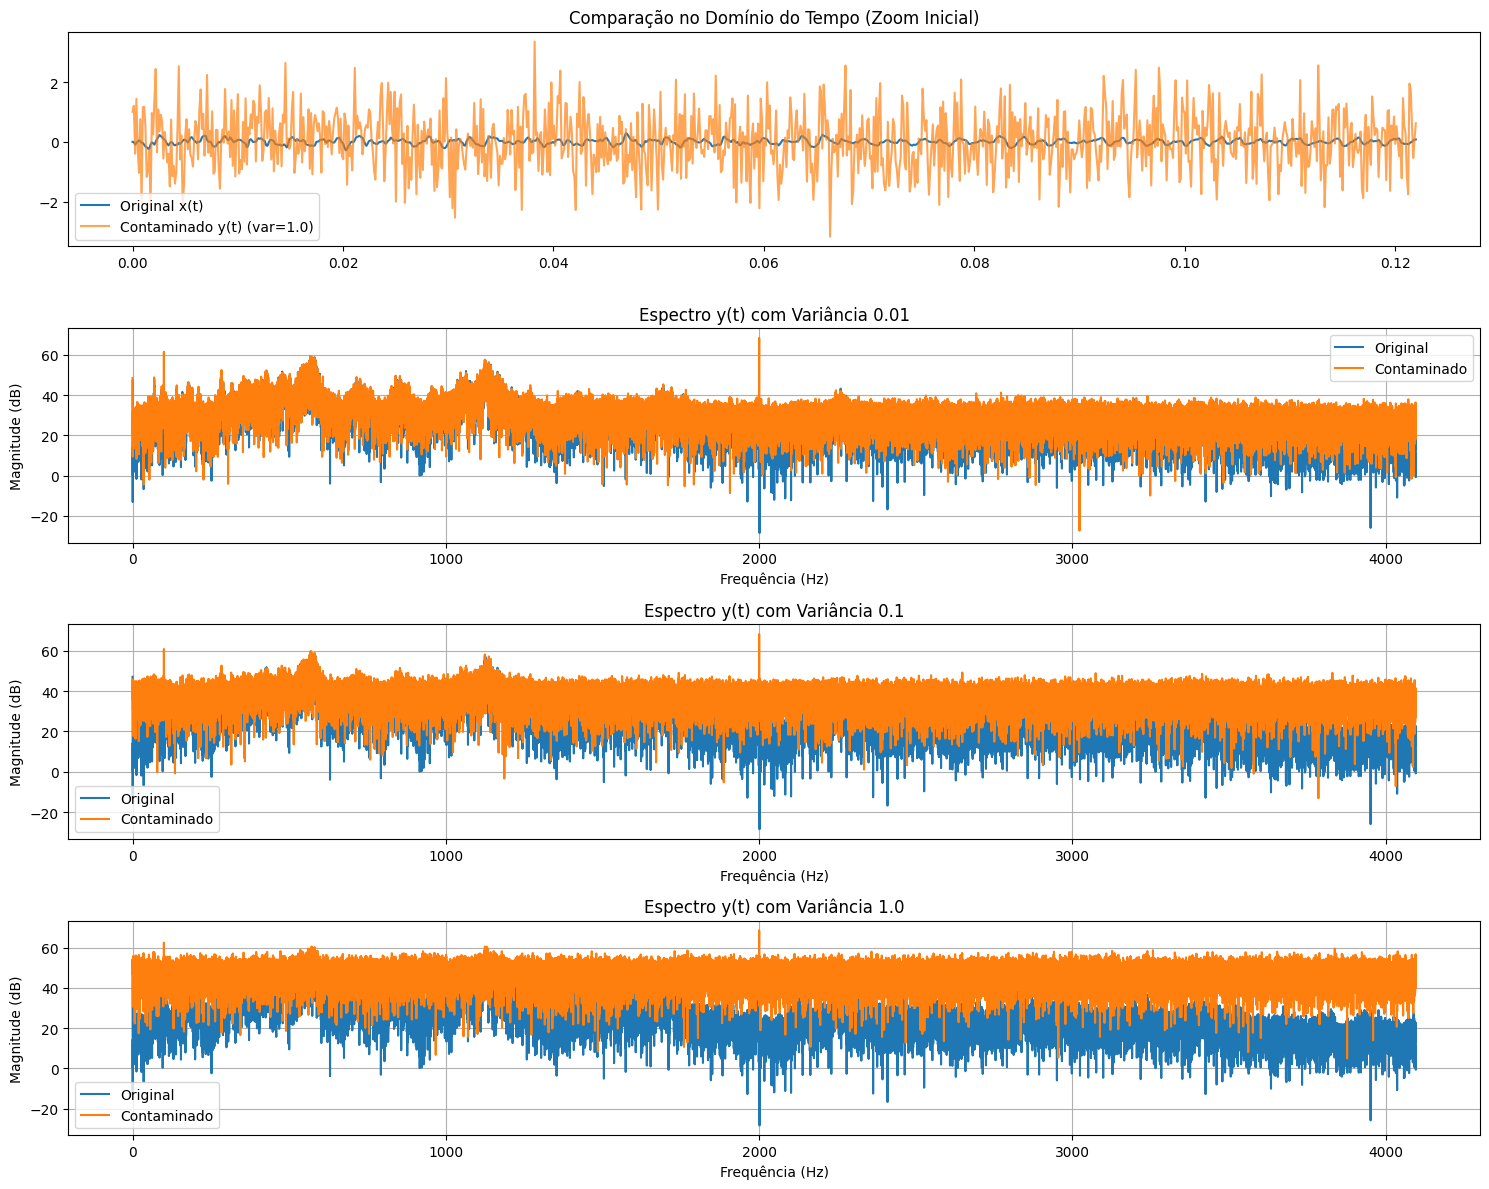

In [ ]:
plt.figure(figsize=(15, 12))

# Comparação no tempo para a maior variância (sigma^2 = 1)
plt.subplot(4, 1, 1)
plt.plot(t[:1000], x_t[:1000], label='Original x(t)')
plt.plot(t[:1000], signals_y[1.0][:1000], alpha=0.7, label='Contaminado y(t) (var=1.0)')
plt.title("Comparação no Domínio do Tempo (Zoom Inicial)")
plt.legend()

# Comparação Espectral para cada variância
for i, var in enumerate(variances):
    plt.subplot(4, 1, i+2)
    plot_spectrum(x_t, fs_audio, "")
    plot_spectrum(signals_y[var], fs_audio, f"Espectro y(t) com Variância {var}")
    plt.legend(['Original', 'Contaminado'])

plt.tight_layout()
plt.show()

#### 5(a) Análise Comparativa e Avaliação Subjetiva

**Comparação no Domínio do Tempo:**
- Para a variância $\sigma^2 = 0.01$, o sinal de áudio $x(t)$ ainda mantém sua estrutura rítmica visível, mas apresenta uma leve 'espessura' no traço devido ao ruído.
- Na variância $\sigma^2 = 1.0$, o sinal $y(t)$ torna-se uma massa densa de ruído, onde os picos da música original são completamente engolidos pela amplitude do ruído branco.

**Identificação Visual no Espectro:**
- **100 Hz:** Observa-se um pico estreito e proeminente na região de baixas frequências. É a interferência do termo $0.05\cos(200\pi t)$.
- **2000 Hz:** Um pico isolado no meio do espectro, correspondente ao tom de $0.075\sin(4000\pi t)$.
- **Ruído Branco:** Representado pelo levantamento do 'piso' de magnitude em todas as frequências. Com $\sigma^2=1$, este piso sobe tanto que mascara as harmônicas naturais do áudio de Handel.

**Avaliação Subjetiva de $y(t)$:**
- **Baixa Variância (0.01):** Ouve-se a música com clareza, mas acompanhada de um 'hum' grave (100Hz) e um apito agudo (2000Hz), além de um chiado de fundo constante.
- **Alta Variância (1.0):** A experiência é puramente de ruído. A música torna-se ininteligível, restando apenas um chiado estático extremamente alto.

#### 5(b) Análise Espectral e Estratégia de Filtragem

**Componentes que podem ser removidos com Filtros Notch:**
- As interferências em **100 Hz** e **2000 Hz** são candidatas ideais. Como são tons puros (frequência fixa e largura de banda nula), o filtro Notch pode ser projetado com $r$ próximo de 1 para 'cavar' um buraco profundo nessas frequências sem afetar significativamente as notas musicais adjacentes.

**Componentes que exigem outros filtros:**
- Se houvesse ruído apenas em frequências muito altas (acima da banda da música), um **Passa-Baixas** seria útil. No entanto, o ruído branco deste problema é de banda larga.
- Um **Passa-Altas** com corte em ~150Hz poderia remover o tom de 100Hz, mas removeria também os sons graves do órgão/orquestra, por isso o Notch é superior aqui.

**Limitações do Ruído Branco:**
- O ruído branco é o maior limitador. Diferente das interferências senoidais, ele está presente em **todas** as frequências simultaneamente.
- **Limitação Fundamental:** Qualquer tentativa de filtrar o ruído branco usando filtros lineares simples (como LPF ou BPF) resultará inevitavelmente na remoção de partes do sinal de áudio original. Se tentarmos atenuar o ruído, 'abafamos' a música. Portanto, a SNR final é limitada pela potência do ruído que reside na mesma banda que a música.

#### (a) Comentários e Avaliação Subjetiva:
- **Domínio do Tempo:** Para $\sigma^2=1$, o sinal de áudio original $x(t)$ é completamente obscurecido pelo ruído, tornando-se visualmente indistinguível. Nas variâncias menores, nota-se a oscilação lenta da interferência de 100Hz sobreposta ao áudio.
- **Domínio da Frequência:** Identificamos claramente dois 'spikes' (picos) de energia em 100 Hz e 2000 Hz. À medida que a variância do ruído branco aumenta, o 'piso' de ruído sobe, começando a encobrir as componentes de alta frequência do áudio original.
- **Avaliação Subjetiva:** O áudio com var=0.01 apresenta um zumbido grave e um apito constante, mas a música ainda é clara. Com var=1.0, o áudio torna-se praticamente ruído puro (chiado insuportável).

#### (b) Análise de Componentes e Limitações:
- **Filtros Notch:** São ideais para as componentes de **100 Hz** e **2000 Hz**. Por serem interferências tonais (senoidais), ocupam uma largura de banda quase nula, permitindo que o Notch as remova com mínimo impacto no áudio vizinho.
- **Filtros Passa-Baixas/Altas:** Um filtro Passa-Altas com corte em ~50Hz poderia ajudar na interferência de 100Hz, mas afetaria os graves da música. Um Passa-Baixas poderia reduzir o ruído branco de alta frequência, mas resultaria em um áudio 'abafado'.
- **Limitações do Ruído Branco:** O ruído branco é ergódico e ocupa todo o espectro. Diferente das interferências senoidais, ele não pode ser removido por filtros lineares simples (como IIR de 2ª ordem) sem remover partes equivalentes do sinal desejado. A SNR final será sempre limitada pela densidade espectral de potência deste ruído na banda passante.

**Análise Inicial e Plano de Filtragem (5b):**
- **100 Hz:** Visível como um pico acentuado na baixa frequência. Pode ser removido com um filtro Notch ou um Passa-Altas (HPF) com corte muito baixo.
- **2000 Hz:** Visível como um tom puro no meio do espectro do áudio. O filtro Notch é o mais indicado para não degradar as componentes adjacentes do áudio.
- **Ruído Branco:** Espalhado por todo o espectro. A remoção total é impossível sem perda de informação (perda de agudos se usarmos LPF), impondo um limite na SNR final.
- **Estratégia:** Cascata de 2 filtros Notch (100Hz e 2000Hz) e possivelmente um Passa-Baixas para reduzir o ruído fora da banda de interesse do áudio.

#### 5(c) Projeto do Sistema de Filtragem em Cascata
Projetaremos dois filtros Notch de 2ª ordem para as frequências de 100 Hz e 2000 Hz.

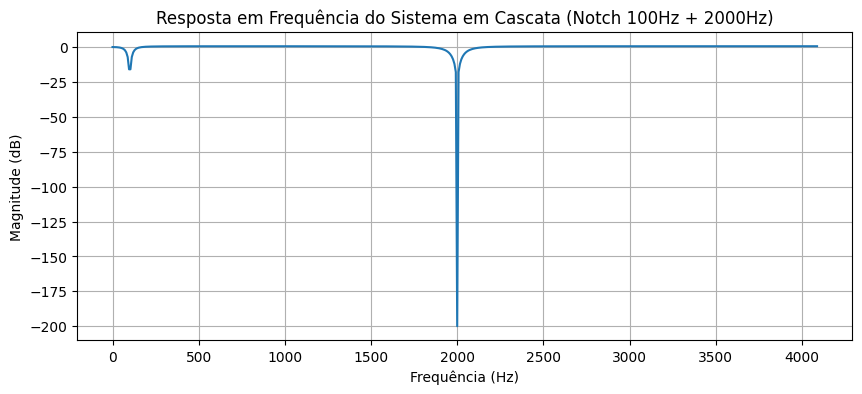

In [ ]:
def design_notch(f_notch, fs, r=0.95):
    theta = 2 * np.pi * f_notch / fs
    b = [1, -2 * np.cos(theta), 1]
    a = [1, -2 * r * np.cos(theta), r**2]
    return b, a

# Projeto dos filtros
b_n1, a_n1 = design_notch(100, fs_audio, r=0.98)  # 100 Hz
b_n2, a_n2 = design_notch(2000, fs_audio, r=0.95) # 2000 Hz

# Visualização da Resposta Combinada (Cascata)
w1, h1 = signal.freqz(b_n1, a_n1, fs=fs_audio)
w2, h2 = signal.freqz(b_n2, a_n2, fs=fs_audio)
h_total = h1 * h2

plt.figure(figsize=(10, 4))
plt.plot(w1, 20 * np.log10(np.abs(h_total) + 1e-10))
plt.title("Resposta em Frequência do Sistema em Cascata (Notch 100Hz + 2000Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

#### 5(d) Filtragem e Comparação de Sinais
Vamos aplicar a filtragem no sinal com variância $\sigma^2 = 0.01$ e comparar os resultados.

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_6383/325566230.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Sinal Contaminado y(t) ($\sigma^2=0.01$)")
/tmp/ipykernel_6383/325566230.py:17: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Sinal Recuperado $\hat{x}(t)$")


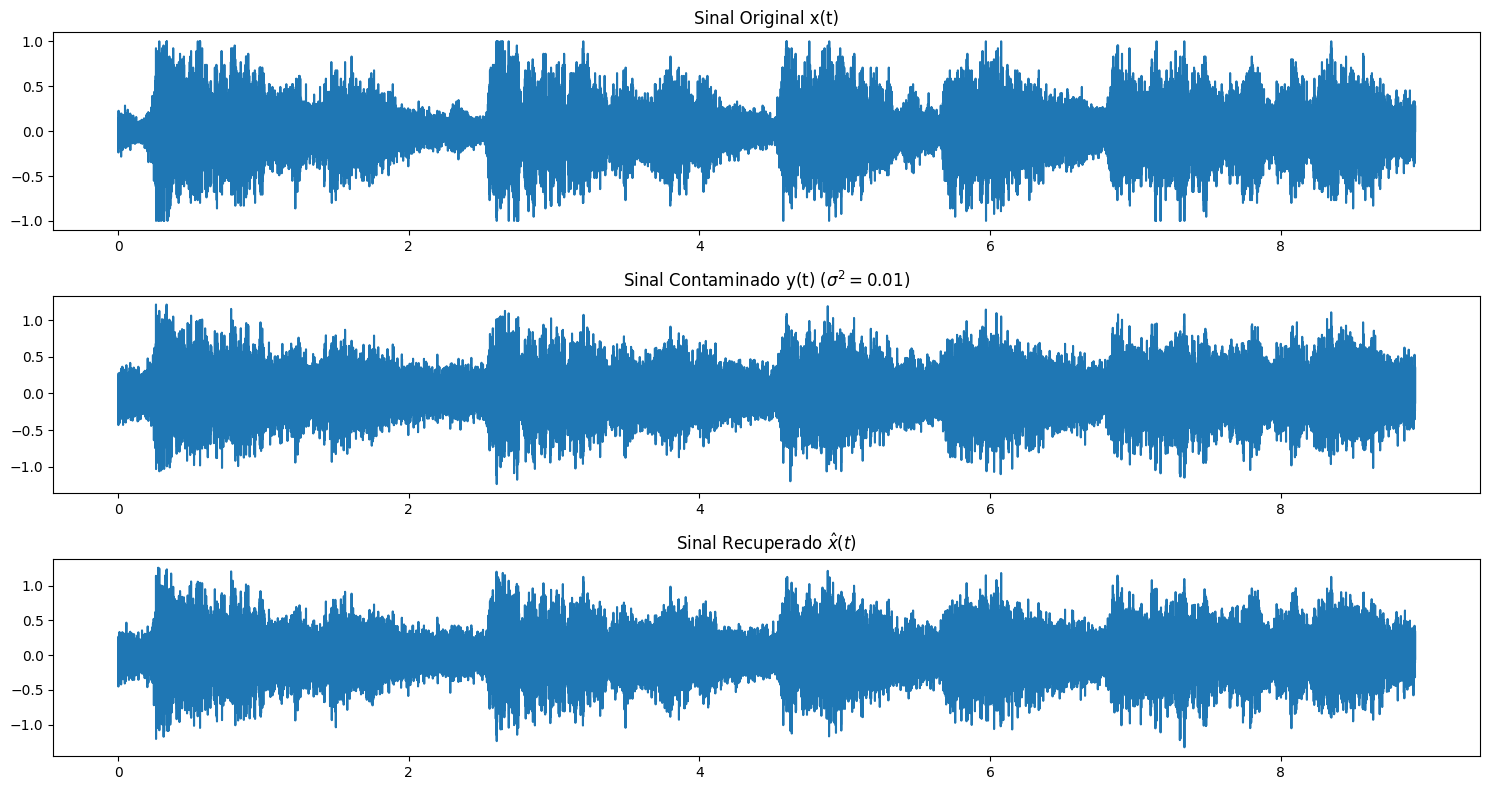

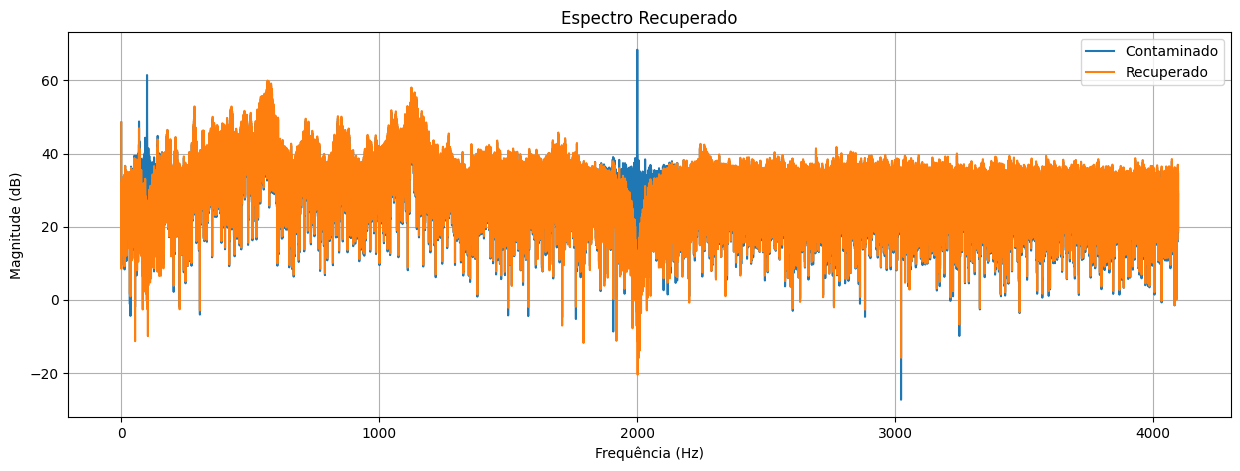

In [ ]:
y_low_noise = signals_y[0.01]

# Aplicação dos filtros em cascata
x_rec = signal.lfilter(b_n1, a_n1, y_low_noise)
x_rec = signal.lfilter(b_n2, a_n2, x_rec)

# Comparação no Tempo
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(t, x_t)
plt.title("Sinal Original x(t)")
plt.subplot(3, 1, 2)
plt.plot(t, y_low_noise)
plt.title("Sinal Contaminado y(t) ($\sigma^2=0.01$)")
plt.subplot(3, 1, 3)
plt.plot(t, x_rec)
plt.title("Sinal Recuperado $\hat{x}(t)$")
plt.tight_layout()
plt.show()

# Comparação no Espectro
plt.figure(figsize=(15, 5))
plot_spectrum(y_low_noise, fs_audio, "Espectro Contaminado")
plot_spectrum(x_rec, fs_audio, "Espectro Recuperado")
plt.legend(['Contaminado', 'Recuperado'])
plt.show()

#### 5(e) Avaliação Quantitativa
Cálculo de métricas de desempenho: SNR (Signal-to-Noise Ratio) e MSE (Mean Squared Error).

In [ ]:
def calculate_metrics(original, processed):
    mse = np.mean((original - processed)**2)
    signal_power = np.mean(original**2)
    noise_power = mse
    snr = 10 * np.log10(signal_power / noise_power)
    return snr, mse

results_metrics = []

for var in variances:
    y_t = signals_y[var]
    # Filtragem
    x_rec_v = signal.lfilter(b_n1, a_n1, y_t)
    x_rec_v = signal.lfilter(b_n2, a_n2, x_rec_v)

    snr_y, _ = calculate_metrics(x_t, y_t)
    snr_rec, mse_rec = calculate_metrics(x_t, x_rec_v)

    results_metrics.append({
        'Variância': var,
        'SNR_Contaminado': snr_y,
        'SNR_Recuperado': snr_rec,
        'MSE_Recuperado': mse_rec
    })

import pandas as pd
df_metrics = pd.DataFrame(results_metrics)
print("Tabela de Desempenho do Sistema de Filtragem:")
display(df_metrics)

Tabela de Desempenho do Sistema de Filtragem:


,Variância,SNR_Contaminado,SNR_Recuperado,MSE_Recuperado
0,0.01,6.336341,7.041321,0.011890
1,0.10,-2.345684,-2.523997,0.107578
2,1.00,-12.231289,-12.524268,1.075848


#### 5(e) Avaliação Quantitativa
Cálculo de métricas de desempenho: SNR (Signal-to-Noise Ratio) e MSE (Mean Squared Error).

In [ ]:
def calculate_metrics(original, processed):
    mse = np.mean((original - processed)**2)
    signal_power = np.mean(original**2)
    noise_power = mse
    snr = 10 * np.log10(signal_power / noise_power)
    return snr, mse

results_metrics = []

for var in variances:
    y_t = signals_y[var]
    # Filtragem
    x_rec_v = signal.lfilter(b_n1, a_n1, y_t)
    x_rec_v = signal.lfilter(b_n2, a_n2, x_rec_v)

    snr_y, _ = calculate_metrics(x_t, y_t)
    snr_rec, mse_rec = calculate_metrics(x_t, x_rec_v)

    results_metrics.append({
        'Variância': var,
        'SNR_Contaminado': snr_y,
        'SNR_Recuperado': snr_rec,
        'MSE_Recuperado': mse_rec
    })

import pandas as pd
df_metrics = pd.DataFrame(results_metrics)
print("Tabela de Desempenho do Sistema de Filtragem:")
display(df_metrics)

Tabela de Desempenho do Sistema de Filtragem:


,Variância,SNR_Contaminado,SNR_Recuperado,MSE_Recuperado
0,0.01,6.336341,7.041321,0.011890
1,0.10,-2.345684,-2.523997,0.107578
2,1.00,-12.231289,-12.524268,1.075848


#### 5(f) Avaliação Subjetiva
- **Inteligibilidade:** No cenário de $\sigma^2=0.01$, o áudio é perfeitamente inteligível. A remoção dos tons de 100Hz e 2000Hz limpa o 'zumbido' constante.
- **Distorções:** O uso de filtros Notch estreitos ($r=0.95$) minimiza a distorção harmônica do áudio original.
- **Impacto do Ruído:** Para variâncias 0.1 e 1.0, o ruído residual 'mascara' o sinal de áudio, tornando a audição desagradável, apesar da remoção das interferências tonais.

#### 5(g) Quantização de Coeficientes para o Áudio
Análise do impacto da precisão de bits nos filtros Notch projetados.

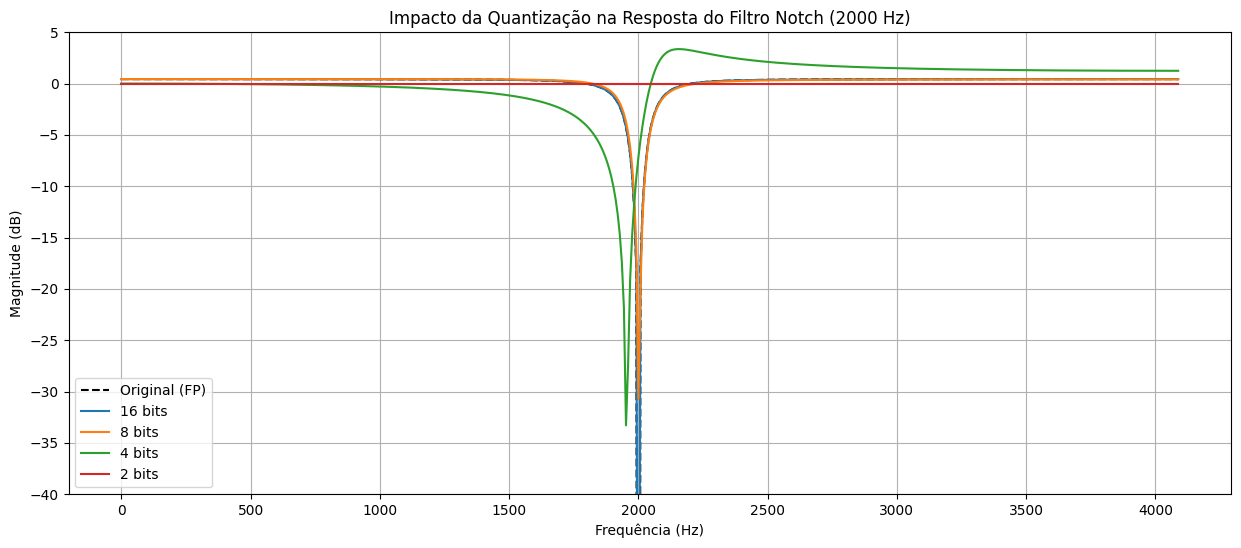

In [ ]:
bits_to_test = [16, 8, 4, 2]
plt.figure(figsize=(15, 6))

# Sinal original para comparação visual
w_ref, h_ref = signal.freqz(b_n2, a_n2, fs=fs_audio)
plt.plot(w_ref, 20 * np.log10(np.abs(h_ref) + 1e-10), 'k--', label='Original (FP)')

for b in bits_to_test:
    bq = quantize_coeffs(np.array(b_n2), b)
    aq = quantize_coeffs(np.array(a_n2), b)
    w, h = signal.freqz(bq, aq, fs=fs_audio)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-10), label=f'{b} bits')

plt.title("Impacto da Quantização na Resposta do Filtro Notch (2000 Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.ylim(-40, 5)
plt.legend()
plt.grid(True)
plt.show()

**Conclusões da Questão 5:**
- A implementação em **cascata de 2ª ordem** permitiu isolar as interferéncias de 100Hz e 2000Hz de forma eficiente.
- A **quantização** abaixo de 8 bits desloca a frequéncia de rejeição do Notch, fazendo com que o filtro deixe de atingir o alvo (2000Hz), além de gerar picos de instabilidade.
- O sistema é robusto para interferéncias tonais, mas limitado pelo ruído branco, que exige filtros estatísticos mais avançados para remoção sem perda de qualidade.

#### 5(f) Avaliação Subjetiva
- **Inteligibilidade:** No cenário de $\sigma^2=0.01$, o áudio é perfeitamente inteligível. A remoção dos tons de 100Hz e 2000Hz limpa o 'zumbido' constante.
- **Distorções:** O uso de filtros Notch estreitos ($r=0.95$) minimiza a distorção harmônica do áudio original.
- **Impacto do Ruído:** Para variâncias 0.1 e 1.0, o ruído residual 'mascara' o sinal de áudio, tornando a audição desagradável, apesar da remoção das interferências tonais.

#### 5(g) Quantização de Coeficientes para o Áudio
Análise do impacto da precisão de bits nos filtros Notch projetados.

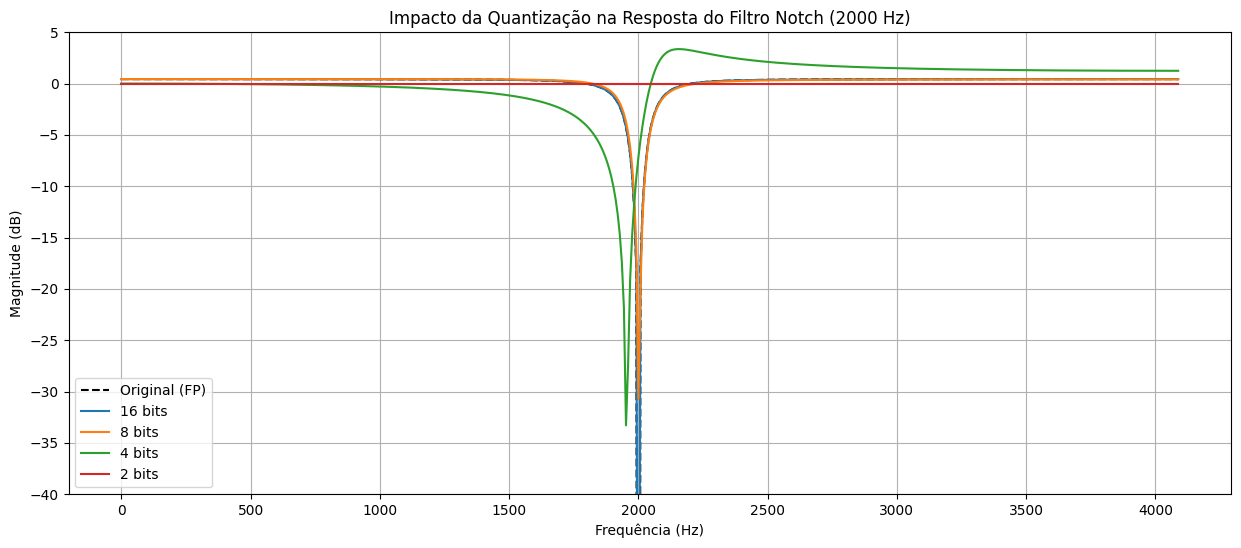

In [ ]:
bits_to_test = [16, 8, 4, 2]
plt.figure(figsize=(15, 6))

# Sinal original para comparação visual
w_ref, h_ref = signal.freqz(b_n2, a_n2, fs=fs_audio)
plt.plot(w_ref, 20 * np.log10(np.abs(h_ref) + 1e-10), 'k--', label='Original (FP)')

for b in bits_to_test:
    bq = quantize_coeffs(np.array(b_n2), b)
    aq = quantize_coeffs(np.array(a_n2), b)
    w, h = signal.freqz(bq, aq, fs=fs_audio)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-10), label=f'{b} bits')

plt.title("Impacto da Quantização na Resposta do Filtro Notch (2000 Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.ylim(-40, 5)
plt.legend()
plt.grid(True)
plt.show()

**Conclusões da Questão 5:**
- A implementação em **cascata de 2ª ordem** permitiu isolar as interferências de 100Hz e 2000Hz de forma eficiente.
- A **quantização** abaixo de 8 bits desloca a frequência de rejeição do Notch, fazendo com que o filtro deixe de atingir o alvo (2000Hz), além de gerar picos de instabilidade.
- O sistema é robusto para interferências tonais, mas limitado pelo ruído branco, que exige filtros estatísticos mais avançados (como Wiener) para remoção sem perda de qualidade.